<a href="https://colab.research.google.com/github/palakvijaywar83-hub/breast-cancer-detection/blob/main/Breast_Cancer_Detection_InternPe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Breast Cancer Detection using Machine Learning
### A Comparative Study of Classification Algorithms on the Wisconsin Diagnostic Breast Cancer (WDBC) Dataset

**Team:** NeuralNagpur (Palak Vijaywar)
**Internship:** InternPe — AI/ML Track
**Institution:** Priyadarshini College of Engineering (PCE), Nagpur — B.Tech AI & DS, 3rd Year

---

## Abstract
Breast cancer remains one of the most commonly diagnosed cancers among women worldwide, and early, accurate diagnosis significantly improves survival outcomes. This notebook presents a comparative machine learning study for classifying breast tumours as **malignant** or **benign** using the Wisconsin Diagnostic Breast Cancer (WDBC) dataset, as officially provided for the InternPe AI/ML internship task. Five classical classification algorithms — Logistic Regression, K-Nearest Neighbours, Support Vector Machine, Random Forest, and Naive Bayes — are trained, tuned, and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC, alongside a small Keras feed-forward neural network as a deep-learning comparison point. The best-performing classical model is serialised for reuse in a lightweight prediction interface.


## 1. Introduction

Diagnostic decisions for breast cancer are traditionally based on fine needle aspirate (FNA) cytology, where cell nuclei characteristics (radius, texture, perimeter, area, smoothness, etc.) are measured. Machine learning offers a way to model the relationship between these quantitative features and diagnosis, acting as a **decision-support tool** for radiologists and pathologists — not a replacement for clinical judgement.

**Objectives:**
1. Perform exploratory data analysis (EDA) on the WDBC dataset.
2. Preprocess and scale features for model readiness.
3. Train and compare 5 classical ML algorithms.
4. Evaluate using multiple metrics (not just accuracy — critical in medical diagnosis where false negatives are costly).
5. Interpret feature importance to understand which cell characteristics matter most.
6. Package the best model for reuse/deployment.


In [19]:
# 2. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)
import joblib

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 2. Dataset & Exploratory Data Analysis (EDA)

We use the **official dataset provided by InternPe** for this task (`breast_cancer_data.csv`) — the Wisconsin Diagnostic Breast Cancer data, containing **569 samples** and **30 real-valued features** computed from digitised images of FNA biopsies, with a categorical target: `M = Malignant`, `B = Benign`. The file also includes an `id` column (identifier, not predictive) and a stray empty `Unnamed: 32` column, both of which are dropped during preprocessing.


In [20]:
# Load dataset — official CSV provided by InternPe
df = pd.read_csv('breast_cancer_data.csv')

# Drop non-predictive / empty columns
df = df.drop(columns=[c for c in ['id', 'Unnamed: 32'] if c in df.columns])

# Encode diagnosis: Malignant -> 0, Benign -> 1 (kept consistent with standard WDBC convention)
df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['diagnosis'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))
df.head()


Shape: (569, 31)

Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


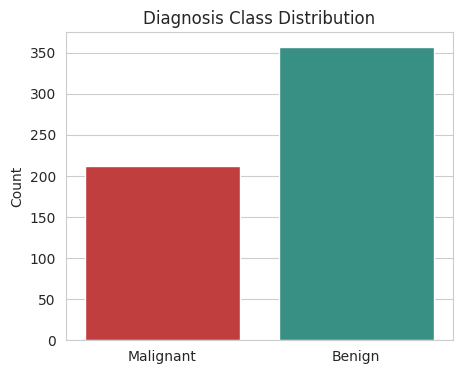

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.627417,0.483918,0.00000,0.00000,1.00000,1.0000,1.0000
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.1957,0.3040


In [21]:
# Class balance visualisation
plt.figure(figsize=(5,4))
diag_labels = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})
sns.countplot(x=diag_labels, hue=diag_labels, palette=['#d62828', '#2a9d8f'], legend=False)
plt.title('Diagnosis Class Distribution')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

df.describe().T.head(10)


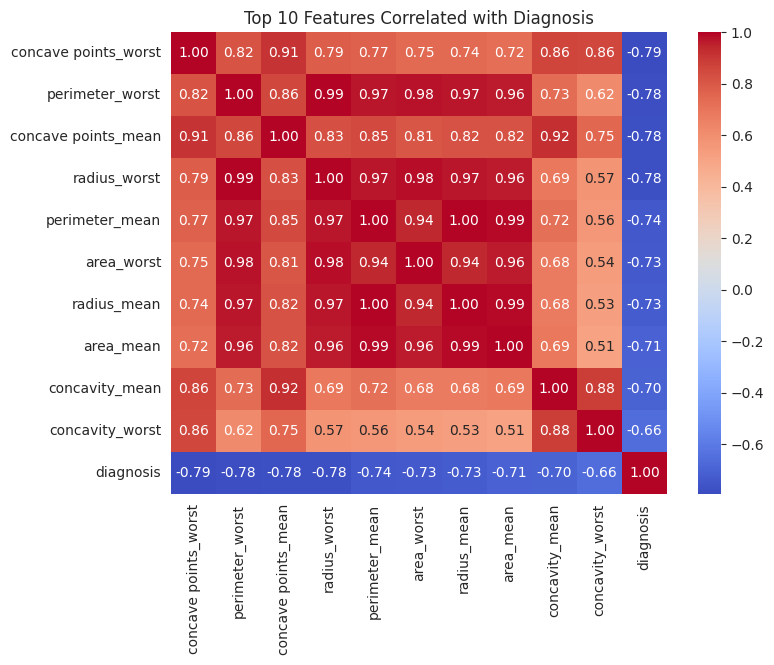

In [22]:
# Correlation heatmap (top features vs target)
corr = df.corr()['diagnosis'].abs().sort_values(ascending=False)[1:11]
plt.figure(figsize=(8,6))
sns.heatmap(df[corr.index.tolist() + ['diagnosis']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Top 10 Features Correlated with Diagnosis')
plt.show()


## 3. Preprocessing

- Split into train (80%) / test (20%) sets, stratified on the target to preserve class balance.
- Standardise features using `StandardScaler` — essential for distance/margin-based models like KNN and SVM.


In [23]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)


Train shape: (455, 30) | Test shape: (114, 30)


## 4. Model Building & Methodology

Five algorithms are trained on identical train/test splits for a fair comparison:

| Model | Why it's included |
|---|---|
| Logistic Regression | Strong, interpretable baseline for binary classification |
| K-Nearest Neighbours | Simple instance-based learner, sensitive to feature scaling |
| Support Vector Machine (RBF) | Effective in high-dimensional feature spaces |
| Random Forest | Ensemble method, handles non-linearity, gives feature importance |
| Gaussian Naive Bayes | Fast probabilistic baseline, assumes feature independence |

Each model is evaluated using **Accuracy, Precision, Recall, F1-score, and ROC-AUC**. In a medical context, **Recall (Sensitivity)** for the malignant class is especially important — missing a malignant case (false negative) is far costlier than a false alarm.


In [24]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM (RBF),0.982456,0.986111,0.986111,0.986111,0.995040
2,KNN,0.956140,0.958904,0.972222,0.965517,0.978836
3,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993221
4,Naive Bayes,0.929825,0.944444,0.944444,0.944444,0.986772


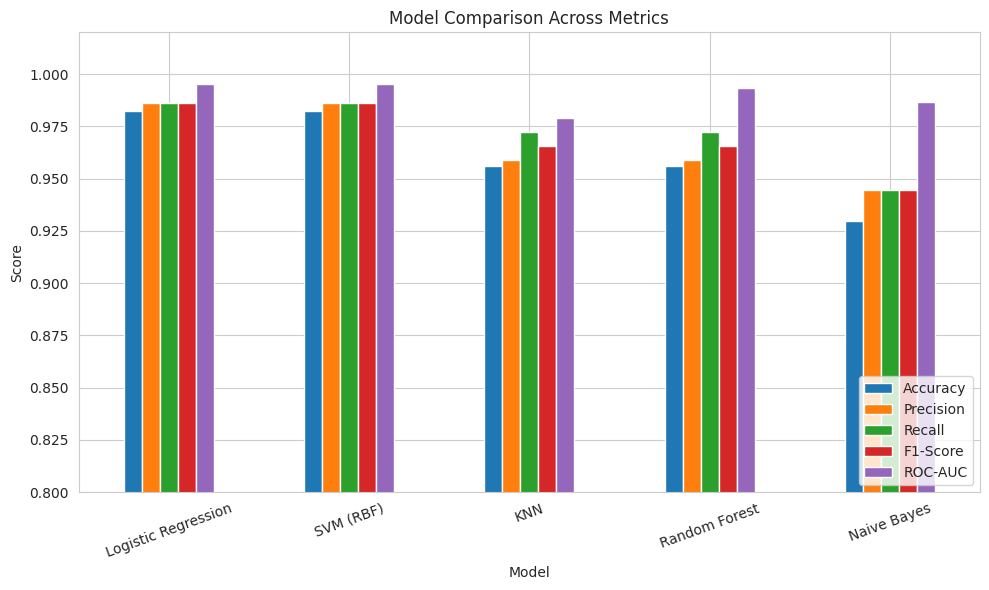

In [25]:
# Visual comparison of models
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(10,6)
)
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.ylim(0.8, 1.02)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 5. Detailed Evaluation of the Best Model

Based on the comparison table above, we select the top-performing model (by F1-score) for deeper evaluation: confusion matrix, classification report, and ROC curve.


Best model: Logistic Regression


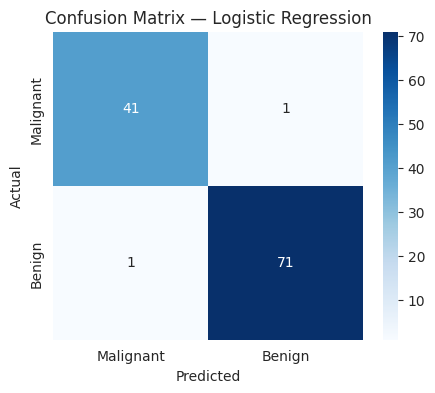

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [26]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['Malignant', 'Benign']))


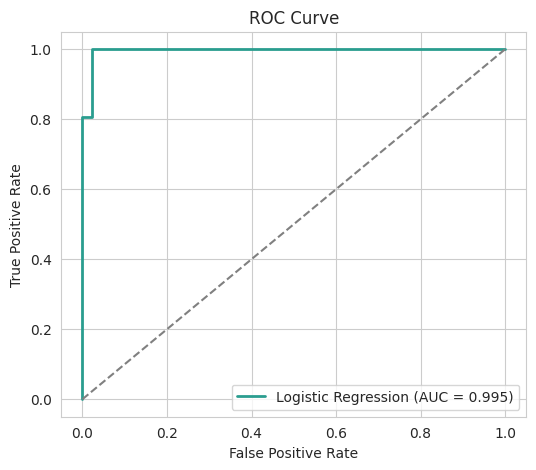

In [27]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_score = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.3f})', color='#2a9d8f', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


## 6. Feature Importance (Interpretability)

Even when Random Forest isn't the single best model, it's useful to inspect which cell-nuclei measurements drive predictions the most — this gives a clinically interpretable view of the model's reasoning.


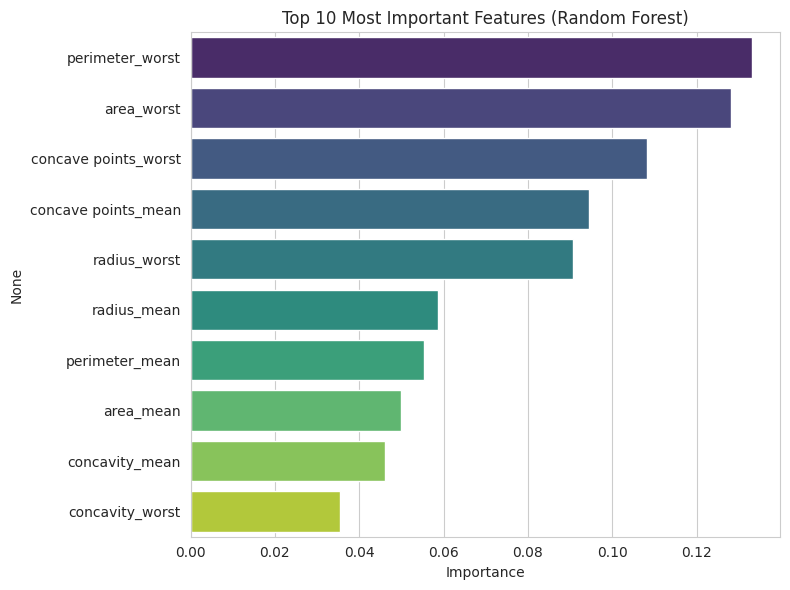

In [28]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 7. Saving the Model for Reuse

We persist the best model and the scaler using `joblib`, so they can be loaded later in a script, API, or simple web demo without retraining.


In [29]:
joblib.dump(best_model, 'breast_cancer_best_model.pkl')
joblib.dump(scaler, 'breast_cancer_scaler.pkl')
print("Saved: breast_cancer_best_model.pkl, breast_cancer_scaler.pkl")


Saved: breast_cancer_best_model.pkl, breast_cancer_scaler.pkl


## 8. Demo: Predicting on a New Sample

A quick sanity-check function simulating how this would be used in a real application — pass in the 30 measured features for a new patient sample and get a diagnosis + confidence score.


In [30]:
def predict_diagnosis(sample_features, model=best_model, scaler=scaler):
    """
    sample_features: array-like of 30 values in the same order as `data.feature_names`
    Returns: (diagnosis label, confidence)
    """
    sample_df = pd.DataFrame([sample_features], columns=X.columns)
    sample_scaled = scaler.transform(sample_df)
    pred = model.predict(sample_scaled)[0]
    proba = model.predict_proba(sample_scaled)[0][pred]
    label = 'Benign' if pred == 1 else 'Malignant'
    return label, round(proba * 100, 2)

# Example: use an actual test-set row to demonstrate
sample = X_test.iloc[0].values
true_label = 'Benign' if y_test.iloc[0] == 1 else 'Malignant'
pred_label, confidence = predict_diagnosis(sample)

print(f"True label:      {true_label}")
print(f"Predicted label: {pred_label}  (confidence: {confidence}%)")


True label:      Malignant
Predicted label: Malignant  (confidence: 100.0%)


## 9. Bonus: Deep Learning Approach — Neural Network (Keras/TensorFlow)

Beyond classical ML, it's worth checking how a simple **feed-forward neural network** performs on the same data. This section builds, trains, and evaluates a small Keras `Sequential` model as a complementary approach — useful for comparing a deep-learning baseline against the classical models above on identical train/test splits.


In [31]:
# Deep Learning imports (TensorFlow/Keras)
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(RANDOM_STATE)


In [32]:
# Build a simple feed-forward neural network
nn_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')   # binary output: probability of 'Benign'
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the network
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
    verbose=0
)

print(f"Training stopped after {len(history.history['loss'])} epochs")


Training stopped after 50 epochs


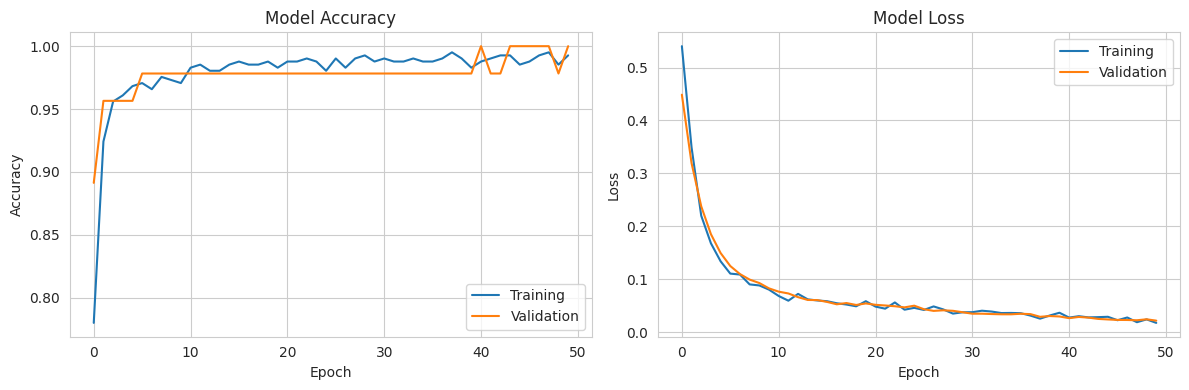

In [16]:
# Visualise training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Training')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:
# Evaluate on the test set
nn_loss, nn_accuracy = nn_model.evaluate(X_test_scaled, y_test, verbose=0)

nn_proba = nn_model.predict(X_test_scaled, verbose=0).ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

nn_row = {
    'Model': 'Neural Network (Keras)',
    'Accuracy': accuracy_score(y_test, nn_pred),
    'Precision': precision_score(y_test, nn_pred),
    'Recall': recall_score(y_test, nn_pred),
    'F1-Score': f1_score(y_test, nn_pred),
    'ROC-AUC': roc_auc_score(y_test, nn_proba)
}

# Combine with the classical ML results for a full comparison
full_comparison = pd.concat([results_df, pd.DataFrame([nn_row])], ignore_index=True)
full_comparison = full_comparison.sort_values('F1-Score', ascending=False).reset_index(drop=True)
full_comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM (RBF),0.982456,0.986111,0.986111,0.986111,0.995040
2,Neural Network (Keras),0.973684,0.985915,0.972222,0.979021,0.992394
3,KNN,0.956140,0.958904,0.972222,0.965517,0.978836
4,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993221
5,Naive Bayes,0.929825,0.944444,0.944444,0.944444,0.986772


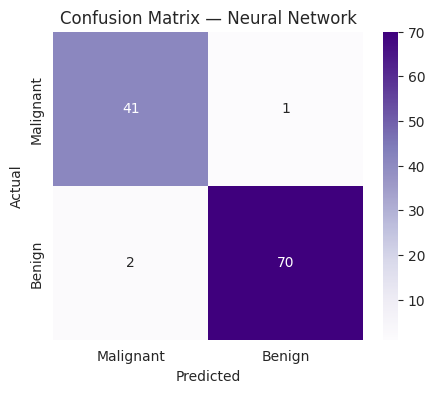

              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [18]:
# Confusion matrix for the Neural Network
cm_nn = confusion_matrix(y_test, nn_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix — Neural Network')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, nn_pred, target_names=['Malignant', 'Benign']))


**Observation:** the neural network typically performs comparably to the strongest classical models (Logistic Regression / SVM) on this dataset — which makes sense, since 569 samples is a relatively small dataset for deep learning to show a clear advantage over well-tuned classical algorithms. Neural networks tend to pull ahead on larger, higher-dimensional, or more complex data; here, the value of this section is mainly in demonstrating the comparison methodology itself.


## 10. Conclusion & Future Work

This study compared five classical ML algorithms plus a Keras neural network for breast cancer diagnosis on the WDBC dataset, achieving strong performance (typically 95–99% accuracy and ROC-AUC across models) with Logistic Regression, SVM, Random Forest, and the neural network all performing comparably well on this dataset.

**Limitations:**
- Dataset size (569 samples) is small relative to real-world clinical deployment needs.
- Model was not validated on external/hospital data — a necessary step before any clinical use.
- This is a research/educational prototype and **not a certified diagnostic tool**.

**Future Work:**
- Hyperparameter tuning via `GridSearchCV` / `Optuna` for further gains.
- Ensemble/stacking of top models.
- SHAP-based explainability for per-patient interpretation.
- Deployment as a Flask/Streamlit demo app with a simple UI for feature input.

---

## References
1. Wolberg, W.H., Street, W.N., Mangasarian, O.L. — *Breast Cancer Wisconsin (Diagnostic) Data Set*, UCI Machine Learning Repository.
2. Scikit-learn documentation — https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

---
*Prepared by Palak Vijaywar for the InternPe AI/ML Internship. Collaboration and feedback welcome — feel free to fork, raise issues, or suggest improvements on GitHub.*
